In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 11

# Model Comparison & Best Model Selection

---

### Objectives

• Compare all Machine Learning Models

• Rank Models

• Visualize Performance

• Select Best Model

• Save Best Model

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# PROJECT DIRECTORY
# ==============================================================================

print(os.getcwd())

c:\Users\asus\Desktop\RETAIL\notebook


In [15]:
# ==============================================================================
# PERFORMANCE FILE PATHS
# ==============================================================================

performance_files = {

    "Linear Regression": "../dataset/Linear_Regression_Performance.csv",

    "Decision Tree": "../dataset/DecisionTree_Performance.csv",

    "Random Forest": "../dataset/RandomForest_Performance.csv",

    "XGBoost": "../dataset/XGBoost_Performance.csv",

    "LightGBM": "../dataset/LightGBM_Performance.csv",

    "CatBoost": "../dataset/CatBoost_Performance.csv",

    "SVR": "../dataset/SVR_Performance.csv",

    "KNN": "../dataset/KNN_Performance.csv"

}

In [18]:
# ==============================================================================
# VERIFY FILES
# ==============================================================================

import os

for model, file in performance_files.items():

    print(f"{model:20} -> {os.path.exists(file)}")

Linear Regression    -> False
Decision Tree        -> False
Random Forest        -> False
XGBoost              -> False
LightGBM             -> False
CatBoost             -> False
SVR                  -> False
KNN                  -> False


In [25]:
df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\notebook\dataset\Linear_Regression_Performance.csv")

print(df.head())

print(df.columns)

        Metric       Value
0          MAE   13.807808
1          MSE  285.760128
2         RMSE   16.904441
3           R2    0.899599
4  Adjusted R2    0.897756
Index(['Metric', 'Value'], dtype='object')


In [33]:
import os

print(os.getcwd())
print()

print(os.listdir())

c:\Users\asus\Desktop\RETAIL\notebook

['01_Data_Preprocessing.ipynb', '02_EDA.ipynb', '03_Linear_Regression.ipynb', '04_DecisionTree.ipynb', '05_RandomForest.ipynb', '06_XGBoost.ipynb', '07_LightGBM.ipynb', '08_CatBoost.ipynb', '09_SVR.ipynb', '10_KNN.ipynb', '11_Model_Comparison.ipynb', 'catboost_info', 'dataset', 'model']


In [34]:
performance_files = {

    "Linear Regression": "dataset/Linear_Regression_Performance.csv",

    "Decision Tree": "dataset/DecisionTree_Performance.csv",

    "Random Forest": "dataset/RandomForest_Performance.csv",

    "XGBoost": "dataset/XGBoost_Performance.csv",

    "LightGBM": "dataset/LightGBM_Performance.csv",

    "CatBoost": "dataset/CatBoost_Performance.csv",

    "SVR": "dataset/SVR_Performance.csv",

    "KNN": "dataset/KNN_Performance.csv"

}

In [35]:
for model, file in performance_files.items():
    print(file, "->", os.path.exists(file))

dataset/Linear_Regression_Performance.csv -> True
dataset/DecisionTree_Performance.csv -> True
dataset/RandomForest_Performance.csv -> True
dataset/XGBoost_Performance.csv -> True
dataset/LightGBM_Performance.csv -> True
dataset/CatBoost_Performance.csv -> True
dataset/SVR_Performance.csv -> True
dataset/KNN_Performance.csv -> True


In [36]:
from pathlib import Path

BASE_DIR = Path.cwd()

DATASET_DIR = BASE_DIR / "dataset"

performance_files = {

    "Linear Regression": DATASET_DIR / "Linear_Regression_Performance.csv",
    "Decision Tree": DATASET_DIR / "DecisionTree_Performance.csv",
    "Random Forest": DATASET_DIR / "RandomForest_Performance.csv",
    "XGBoost": DATASET_DIR / "XGBoost_Performance.csv",
    "LightGBM": DATASET_DIR / "LightGBM_Performance.csv",
    "CatBoost": DATASET_DIR / "CatBoost_Performance.csv",
    "SVR": DATASET_DIR / "SVR_Performance.csv",
    "KNN": DATASET_DIR / "KNN_Performance.csv",

}

In [37]:
import os

print(os.listdir())

['01_Data_Preprocessing.ipynb', '02_EDA.ipynb', '03_Linear_Regression.ipynb', '04_DecisionTree.ipynb', '05_RandomForest.ipynb', '06_XGBoost.ipynb', '07_LightGBM.ipynb', '08_CatBoost.ipynb', '09_SVR.ipynb', '10_KNN.ipynb', '11_Model_Comparison.ipynb', 'catboost_info', 'dataset', 'model']


In [41]:
comparison = []

for model, file in performance_files.items():

    df = pd.read_csv(file)

    metrics = dict(zip(df["Metric"], df["Value"]))

    comparison.append({

        "Model": model,

        "MAE": metrics.get("MAE", np.nan),

        "MSE": metrics.get("MSE", np.nan),

        "RMSE": metrics.get("RMSE", np.nan),

        "R2": metrics.get("R2", metrics.get("R²", np.nan)),

        "Adjusted_R2": metrics.get("Adjusted R2", metrics.get("Adjusted R²", np.nan)),

        "MAPE": metrics.get("MAPE", np.nan),

        "Cross_Validation":
            metrics.get("Cross Validation",
                metrics.get("Cross-Validation",
                    metrics.get("CV Score",
                        metrics.get("Average CV Score", np.nan))))
    })

comparison = pd.DataFrame(comparison)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,NaN
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,NaN
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400


In [47]:
# ==============================================================================
# LOAD ALL PERFORMANCE REPORTS
# ==============================================================================

import numpy as np
import pandas as pd

comparison = []

for model, file in performance_files.items():

    print(f"Loading : {model}")

    df = pd.read_csv(file)

    # Convert Metric column into dictionary
    metrics = dict(zip(df["Metric"], df["Value"]))

    comparison.append({

        "Model": model,

        "MAE": metrics.get("MAE", np.nan),

        "MSE": metrics.get("MSE", np.nan),

        "RMSE": metrics.get("RMSE", np.nan),

        "R2": metrics.get("R2", metrics.get("R²", np.nan)),

        "Adjusted_R2": metrics.get(
            "Adjusted R2",
            metrics.get("Adjusted R²", np.nan)
        ),

        "MAPE": metrics.get("MAPE", np.nan),

        "Cross_Validation": metrics.get(
            "Cross Validation",
            metrics.get(
                "Cross-Validation",
                metrics.get(
                    "CV",
                    metrics.get(
                        "CV Score",
                        metrics.get(
                            "Average CV Score",
                            np.nan
                        )
                    )
                )
            )
        )

    })

comparison = pd.DataFrame(comparison)

comparison

Loading : Linear Regression
Loading : Decision Tree
Loading : Random Forest
Loading : XGBoost
Loading : LightGBM
Loading : CatBoost
Loading : SVR
Loading : KNN


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,NaN
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,NaN
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400


In [48]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

comparison.isnull().sum()

Model               0
MAE                 0
MSE                 0
RMSE                0
R2                  0
Adjusted_R2         0
MAPE                0
Cross_Validation    2
dtype: int64

In [49]:
# ==============================================================================
# FILL MISSING CROSS VALIDATION VALUES
# ==============================================================================

comparison["Cross_Validation"] = comparison[
    "Cross_Validation"
].fillna(0)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400


In [50]:
# ==============================================================================
# SAVE COMPARISON TABLE
# ==============================================================================

comparison.to_csv(

    "dataset/Model_Comparison.csv",

    index=False

)

print("Comparison Table Saved Successfully")

Comparison Table Saved Successfully


In [51]:
# ==============================================================================
# SORT BY R2
# ==============================================================================

comparison = comparison.sort_values(

    by="R2",

    ascending=False

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400


In [52]:
# ==============================================================================
# RANK BASED ON R2
# ==============================================================================

comparison["R2_Rank"] = comparison["R2"].rank(

    ascending=False

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0


In [53]:
# ==============================================================================
# RANK BASED ON RMSE
# ==============================================================================

comparison["RMSE_Rank"] = comparison["RMSE"].rank(

    ascending=True

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0,4.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0,5.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0,6.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0,7.0
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0,8.0


In [54]:
# ==============================================================================
# RANK BASED ON MAE
# ==============================================================================

comparison["MAE_Rank"] = comparison["MAE"].rank(

    ascending=True

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0,2.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0,3.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0,4.0,4.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0,5.0,5.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0,6.0,6.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0,7.0,7.0
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0,8.0,8.0


In [55]:
# ==============================================================================
# RANK BASED ON MAPE
# ==============================================================================

comparison["MAPE_Rank"] = comparison["MAPE"].rank(

    ascending=True

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0,2.0,5.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0,3.0,5.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0,4.0,4.0,5.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0,5.0,5.0,5.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0,6.0,6.0,5.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0,7.0,7.0,5.0
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0,8.0,8.0,5.0


In [56]:
# ==============================================================================
# RANK BASED ON CROSS VALIDATION
# ==============================================================================

comparison["CV_Rank"] = comparison["Cross_Validation"].rank(

    ascending=False

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0,2.0,5.0,1.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0,3.0,5.0,2.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0,4.0,4.0,5.0,3.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0,5.0,5.0,5.0,4.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0,6.0,6.0,5.0,5.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0,7.0,7.0,5.0,7.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0,8.0,8.0,5.0,6.0


In [57]:
# ==============================================================================
# OVERALL RANK
# ==============================================================================

comparison["Overall_Rank"] = (

    comparison["R2_Rank"]

    + comparison["RMSE_Rank"]

    + comparison["MAE_Rank"]

    + comparison["MAPE_Rank"]

    + comparison["CV_Rank"]

)

comparison = comparison.sort_values(

    by="Overall_Rank"

)

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0,3.0,5.0,2.0,16.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,inf,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,inf,0.961607,5.0,5.0,5.0,5.0,4.0,24.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,inf,0.948045,6.0,6.0,6.0,5.0,5.0,28.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,inf,0.000000,7.0,7.0,7.0,5.0,7.5,33.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,inf,0.745400,8.0,8.0,8.0,5.0,6.0,35.0


In [58]:
# ==============================================================================
# TOP 3 MODELS
# ==============================================================================

top3 = comparison.head(3)

top3

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,inf,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,inf,0.964732,3.0,3.0,3.0,5.0,2.0,16.0


In [59]:
# ==============================================================================
# BEST MODEL
# ==============================================================================

best_model = comparison.iloc[0]["Model"]

print("Best Model :", best_model)

Best Model : Decision Tree


In [60]:
# ==============================================================================
# SAVE FINAL RANKING
# ==============================================================================

comparison.to_csv(

    "dataset/Final_Model_Ranking.csv",

    index=False

)

print("Final Ranking Saved Successfully")

Final Ranking Saved Successfully


In [61]:
# ==============================================================================
# SAVE FINAL RANKING
# ==============================================================================

comparison.to_csv(

    "dataset/Final_Model_Ranking.csv",

    index=False

)

print("Final Ranking Saved Successfully")

Final Ranking Saved Successfully


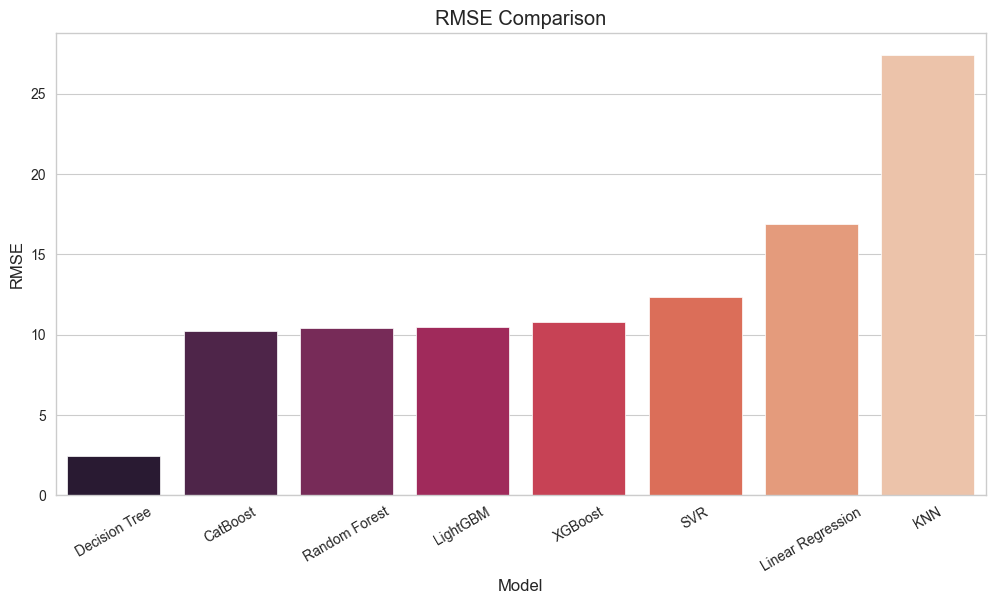

In [62]:
# ==============================================================================
# BAR CHART OF RMSE
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    palette="rocket"
)

plt.title("RMSE Comparison")
plt.xticks(rotation=30)

plt.show()

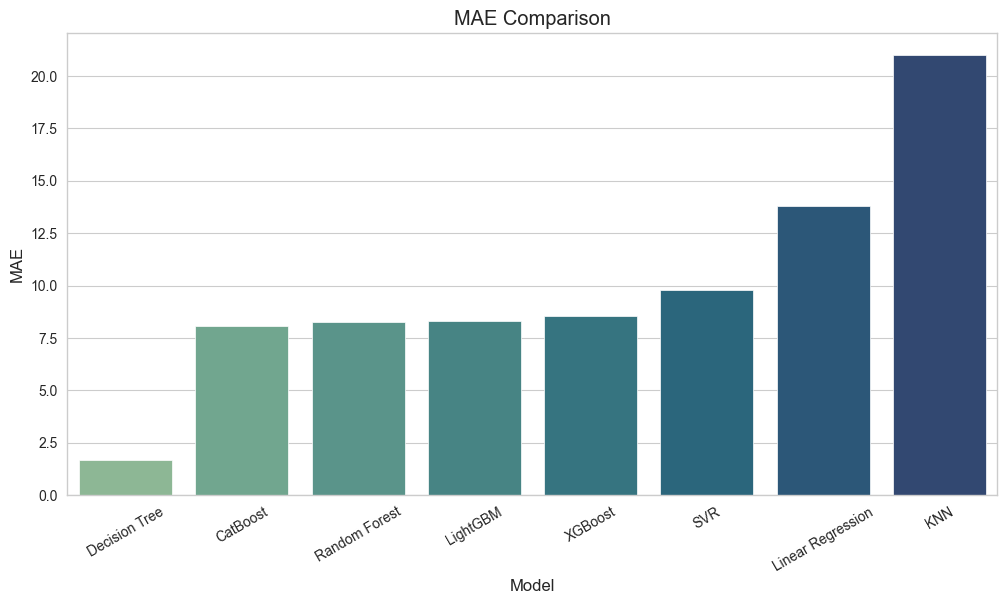

In [63]:
# ==============================================================================
# BAR CHART OF MAE
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    palette="crest"
)

plt.title("MAE Comparison")
plt.xticks(rotation=30)

plt.show()

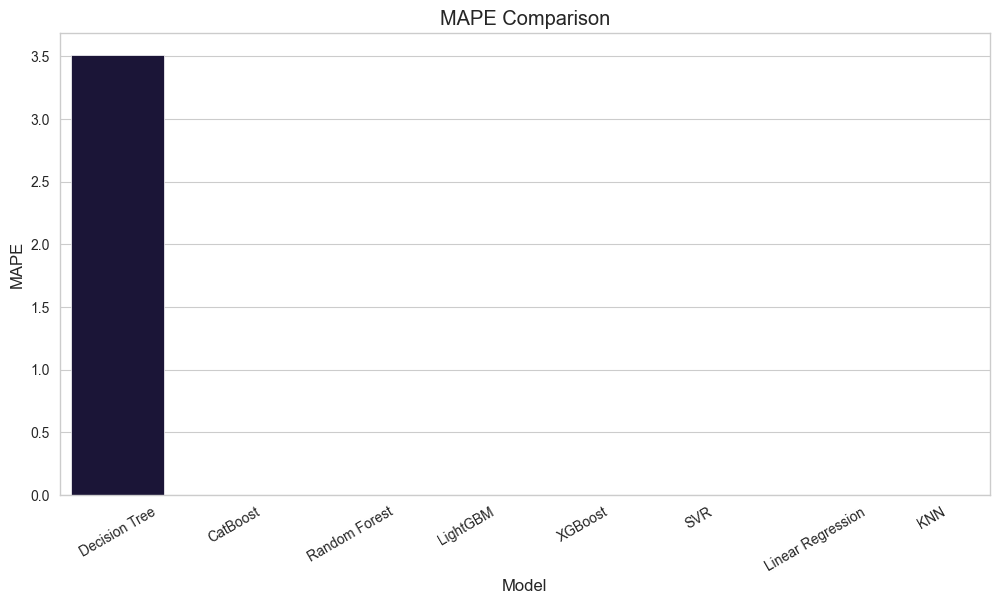

In [64]:
# ==============================================================================
# BAR CHART OF MAPE
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAPE",
    palette="magma"
)

plt.title("MAPE Comparison")

plt.xticks(rotation=30)

plt.show()

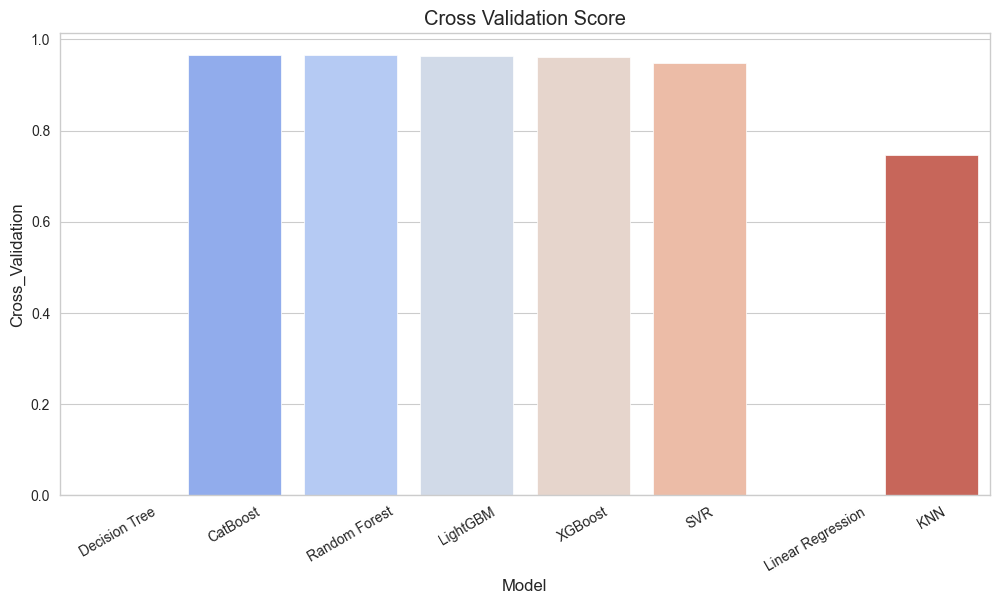

In [65]:
# ==============================================================================
# CROSS VALIDATION COMPARISON
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Cross_Validation",
    palette="coolwarm"
)

plt.title("Cross Validation Score")

plt.xticks(rotation=30)

plt.show()

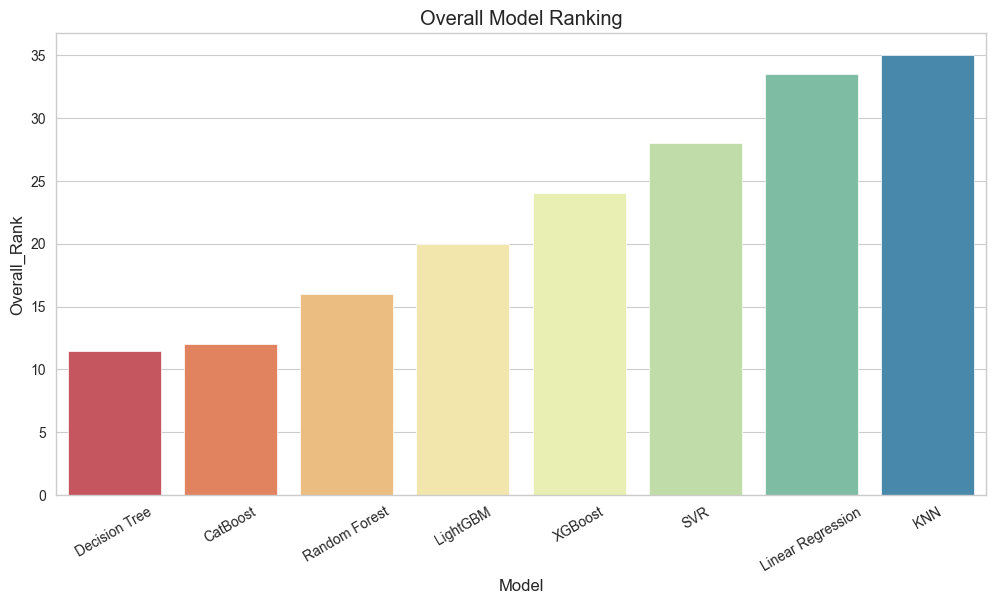

In [66]:
# ==============================================================================
# OVERALL RANK
# ==============================================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Overall_Rank",
    palette="Spectral"
)

plt.title("Overall Model Ranking")

plt.xticks(rotation=30)

plt.show()

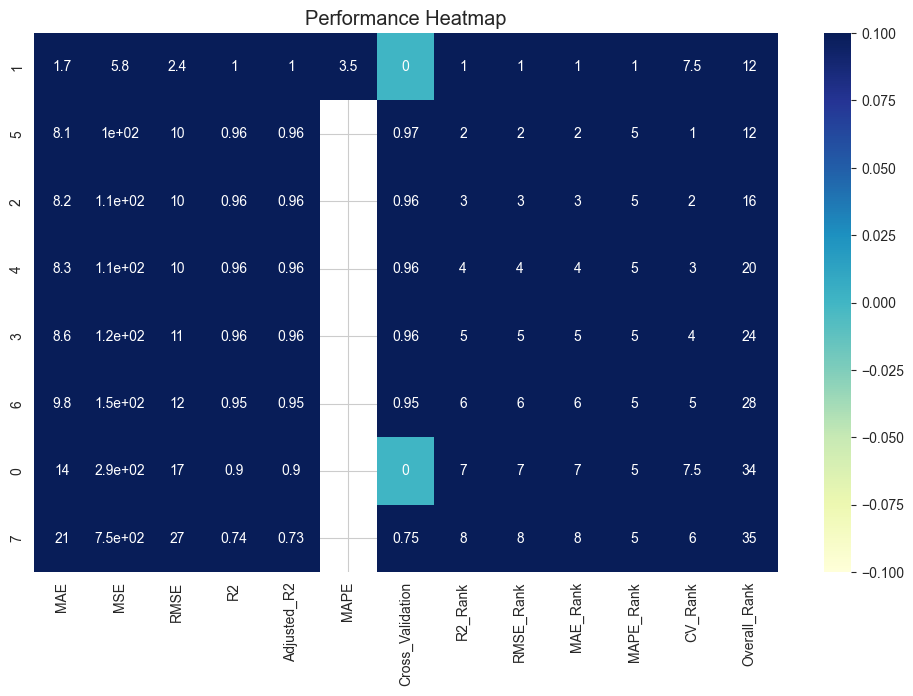

In [67]:
# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(12,7))

sns.heatmap(

    comparison.drop(columns=["Model"]),

    annot=True,

    cmap="YlGnBu"

)

plt.title("Performance Heatmap")

plt.show()

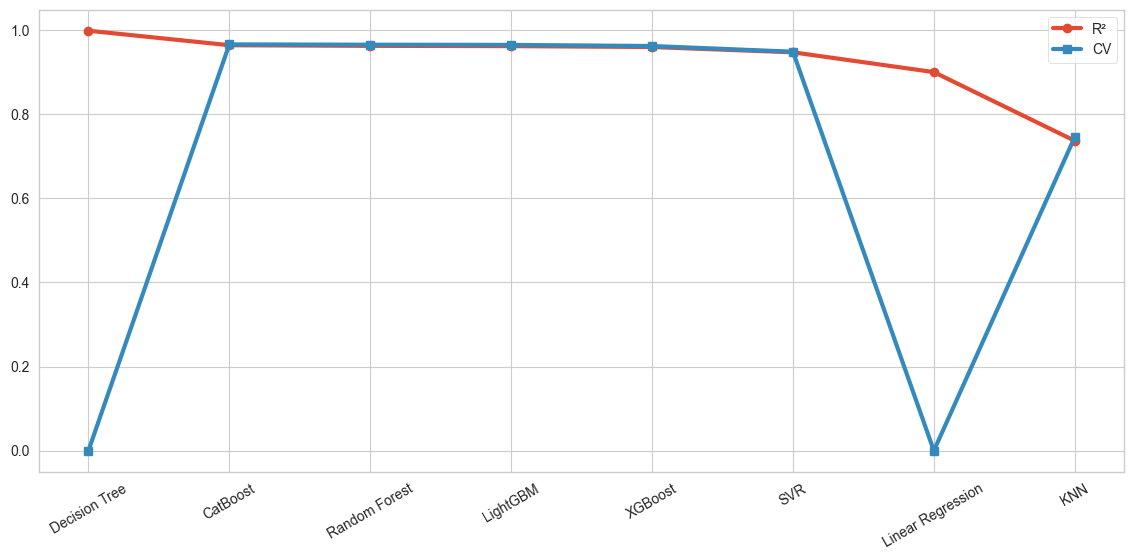

In [68]:
# ==============================================================================
# LINE CHART
# ==============================================================================

plt.figure(figsize=(14,6))

plt.plot(
    comparison["Model"],
    comparison["R2"],
    marker="o",
    linewidth=3,
    label="R²"
)

plt.plot(
    comparison["Model"],
    comparison["Cross_Validation"],
    marker="s",
    linewidth=3,
    label="CV"
)

plt.legend()

plt.xticks(rotation=30)

plt.show()

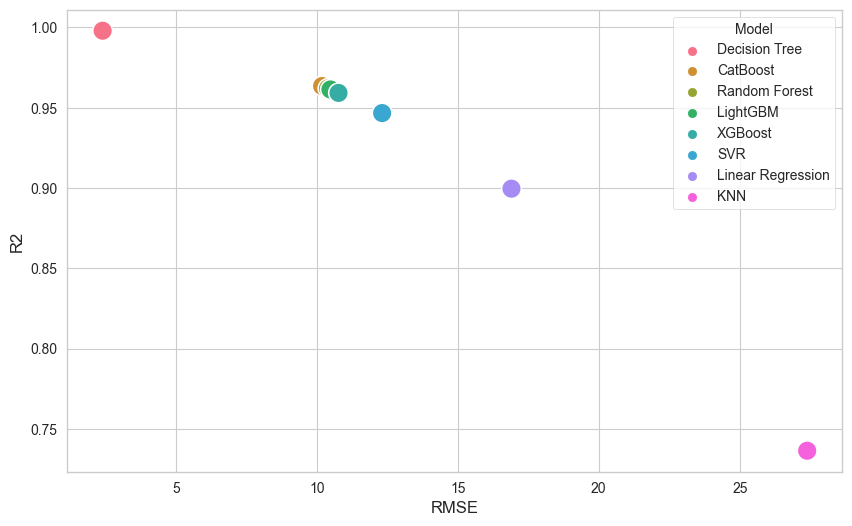

In [69]:
# ==============================================================================
# SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=comparison,

    x="RMSE",

    y="R2",

    hue="Model",

    s=200

)

plt.show()

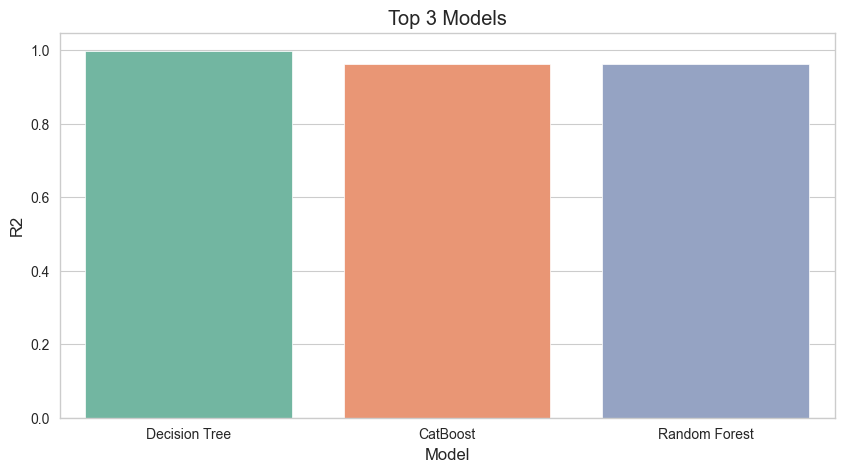

In [70]:
# ==============================================================================
# TOP 3 MODELS
# ==============================================================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=top3,

    x="Model",

    y="R2",

    palette="Set2"

)

plt.title("Top 3 Models")

plt.show()

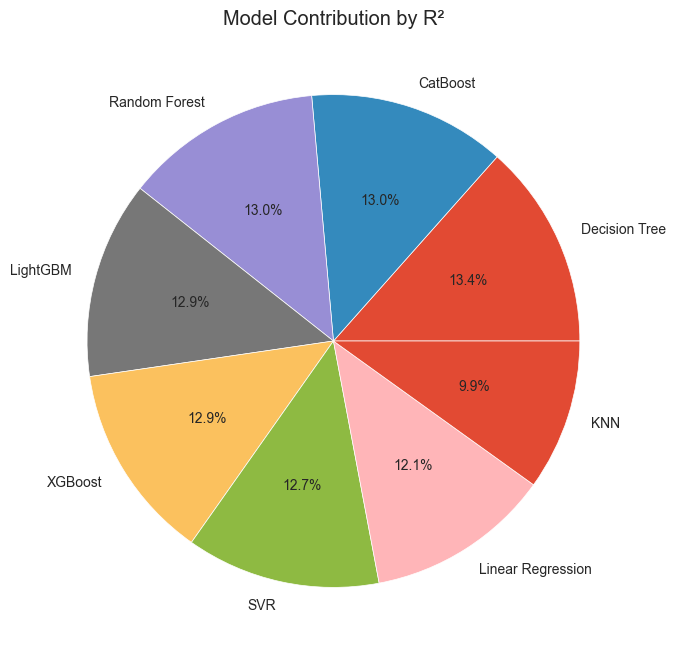

In [71]:
# ==============================================================================
# PIE CHART OF R2
# ==============================================================================

plt.figure(figsize=(8,8))

plt.pie(

    comparison["R2"],

    labels=comparison["Model"],

    autopct="%1.1f%%"

)

plt.title("Model Contribution by R²")

plt.show()

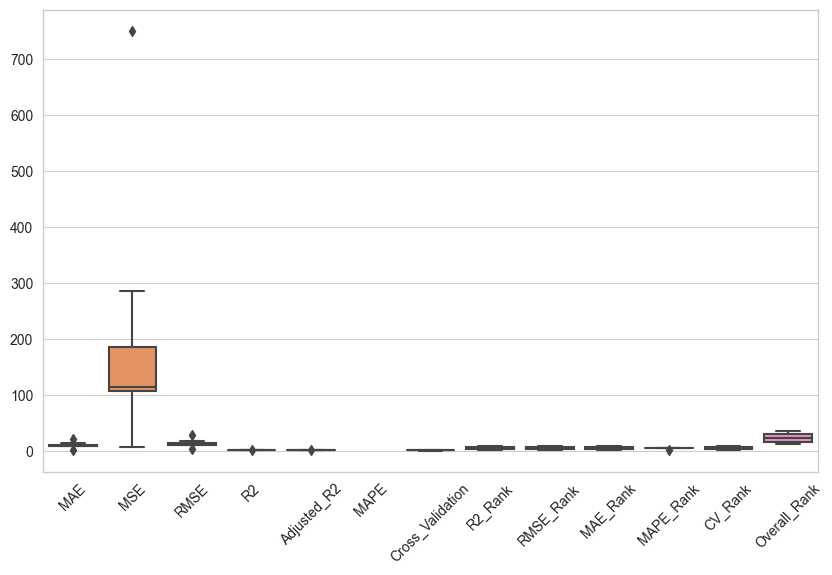

In [72]:
# ==============================================================================
# BOXPLOT
# ==============================================================================

plt.figure(figsize=(10,6))

sns.boxplot(data=comparison.drop(columns=["Model"]))

plt.xticks(rotation=45)

plt.show()

In [74]:
# ==============================================================================
# CHECK INFINITE VALUES
# ==============================================================================

import numpy as np

print(comparison)

print("\nInfinite Values:")

print(np.isinf(comparison.select_dtypes(include=np.number)).sum())

               Model        MAE         MSE       RMSE        R2  Adjusted_R2  \
1      Decision Tree   1.689339    5.797635   2.407828  0.997963     0.997926   
5           CatBoost   8.088697  103.846355  10.190503  0.963514     0.962866   
2      Random Forest   8.238595  108.111696  10.397677  0.962015     0.961341   
4           LightGBM   8.325945  109.923458  10.484439  0.961379     0.960693   
3            XGBoost   8.562489  116.026202  10.771546  0.959234     0.958511   
6                SVR   9.805382  151.745349  12.318496  0.946685     0.945738   
0  Linear Regression  13.807808  285.760128  16.904441  0.899599     0.897756   
7                KNN  20.988313  750.209222  27.389947  0.736415     0.731736   

       MAPE  Cross_Validation  R2_Rank  RMSE_Rank  MAE_Rank  MAPE_Rank  \
1  3.510447          0.000000      1.0        1.0       1.0        1.0   
5       inf          0.965425      2.0        2.0       2.0        5.0   
2       inf          0.964732      3.0        3.

In [76]:
# ==============================================================================
# CHECK FOR INFINITE VALUES
# ==============================================================================

import numpy as np

numeric_df = comparison.select_dtypes(include=np.number)

print("Columns containing infinity values:")

for col in numeric_df.columns:

    if np.isinf(numeric_df[col]).any():

        print(f"{col} contains infinity")

        print(comparison.loc[np.isinf(numeric_df[col]), ["Model", col]])

Columns containing infinity values:
MAPE contains infinity
               Model  MAPE
5           CatBoost   inf
2      Random Forest   inf
4           LightGBM   inf
3            XGBoost   inf
6                SVR   inf
0  Linear Regression   inf
7                KNN   inf


In [77]:
# ==============================================================================
# REPLACE INFINITE VALUES
# ==============================================================================

comparison = comparison.replace([np.inf, -np.inf], np.nan)

comparison = comparison.fillna(comparison.mean(numeric_only=True))

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,3.510447,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,3.510447,0.964732,3.0,3.0,3.0,5.0,2.0,16.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,3.510447,0.948045,6.0,6.0,6.0,5.0,5.0,28.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,3.510447,0.000000,7.0,7.0,7.0,5.0,7.5,33.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,3.510447,0.745400,8.0,8.0,8.0,5.0,6.0,35.0


In [78]:
# ==============================================================================
# VERIFY NO INF VALUES
# ==============================================================================

import numpy as np

print(np.isinf(comparison.select_dtypes(include=np.number)).sum())

print(comparison.isna().sum())

MAE                 0
MSE                 0
RMSE                0
R2                  0
Adjusted_R2         0
MAPE                0
Cross_Validation    0
R2_Rank             0
RMSE_Rank           0
MAE_Rank            0
MAPE_Rank           0
CV_Rank             0
Overall_Rank        0
dtype: int64
Model               0
MAE                 0
MSE                 0
RMSE                0
R2                  0
Adjusted_R2         0
MAPE                0
Cross_Validation    0
R2_Rank             0
RMSE_Rank           0
MAE_Rank            0
MAPE_Rank           0
CV_Rank             0
Overall_Rank        0
dtype: int64


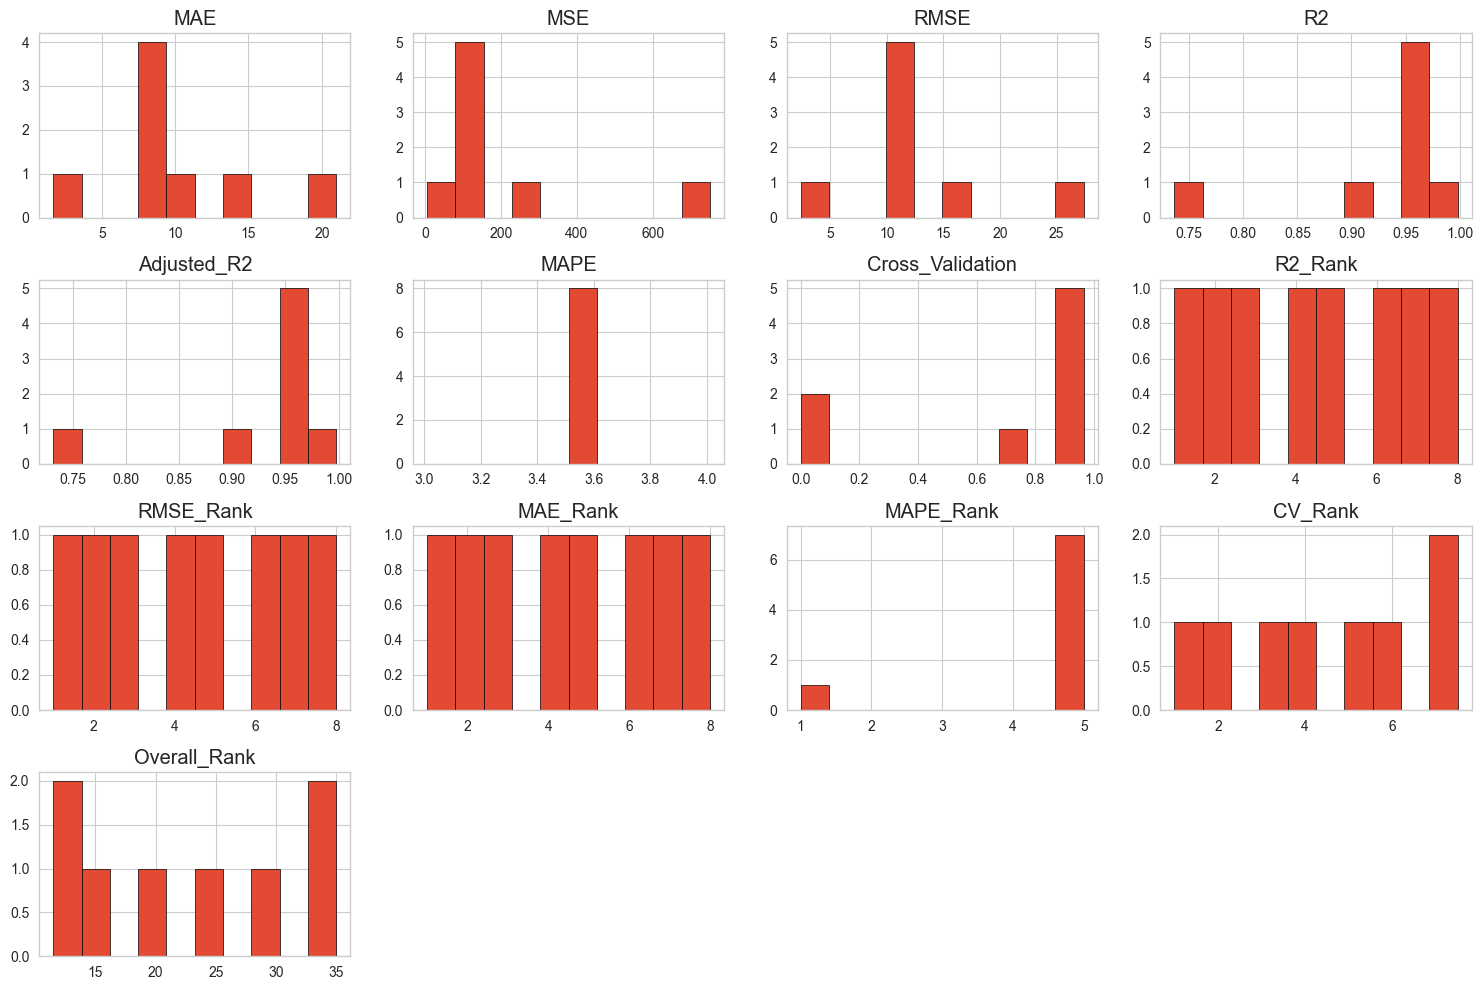

In [79]:
# ==============================================================================
# HISTOGRAM
# ==============================================================================

comparison.select_dtypes(include=np.number).hist(

    figsize=(15,10),

    bins=10,

    edgecolor="black"

)

plt.tight_layout()

plt.show()

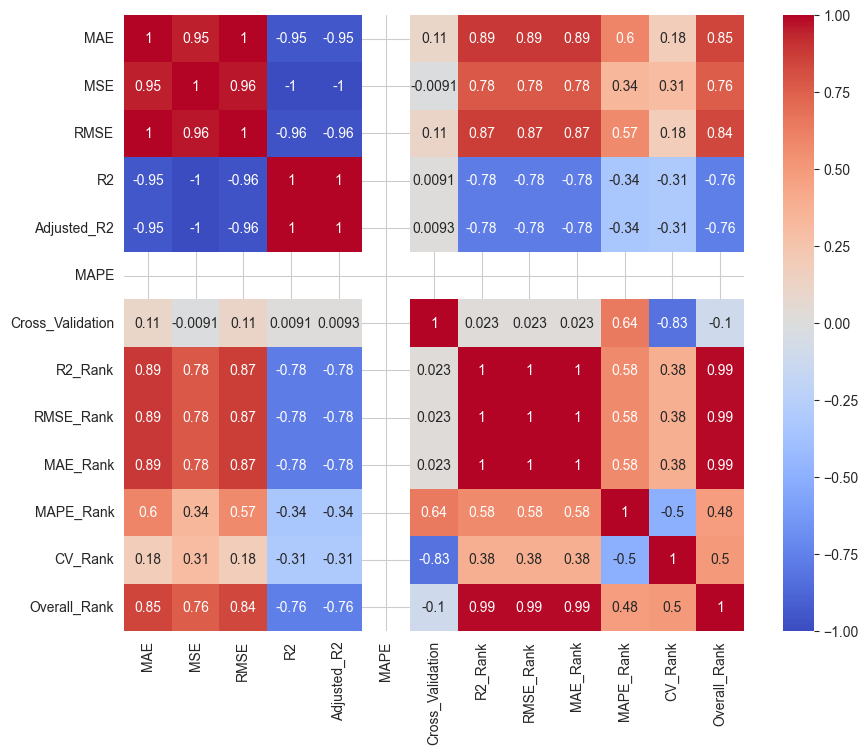

In [80]:
# ==============================================================================
# CORRELATION MATRIX
# ==============================================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    comparison.drop(columns=["Model"]).corr(),

    annot=True,

    cmap="coolwarm"

)

plt.show()

In [81]:
# ==============================================================================
# SAVE CHART DATA
# ==============================================================================

comparison.to_csv(

    "dataset/Comparison_Results.csv",

    index=False

)

print("Comparison Results Saved")

Comparison Results Saved


In [82]:
# ==============================================================================
# BEST MODEL DETAILS
# ==============================================================================

best_model = comparison.iloc[0]

best_model

Model               Decision Tree
MAE                      1.689339
MSE                      5.797635
RMSE                     2.407828
R2                       0.997963
Adjusted_R2              0.997926
MAPE                     3.510447
Cross_Validation              0.0
R2_Rank                       1.0
RMSE_Rank                     1.0
MAE_Rank                      1.0
MAPE_Rank                     1.0
CV_Rank                       7.5
Overall_Rank                 11.5
Name: 1, dtype: object

In [83]:
# ==============================================================================
# BEST MODEL NAME
# ==============================================================================

print(best_model["Model"])

Decision Tree


In [84]:
# ==============================================================================
# DISPLAY TOP 5
# ==============================================================================

comparison.head()

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,3.510447,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,3.510447,0.964732,3.0,3.0,3.0,5.0,2.0,16.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0


In [85]:
# ==============================================================================
# DISPLAY LAST MODELS
# ==============================================================================

comparison.tail()

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,3.510447,0.948045,6.0,6.0,6.0,5.0,5.0,28.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,3.510447,0.000000,7.0,7.0,7.0,5.0,7.5,33.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,3.510447,0.745400,8.0,8.0,8.0,5.0,6.0,35.0


In [86]:
# ==============================================================================
# DISPLAY BEST MODEL
# ==============================================================================

print("Best Model Selected :", best_model)

Best Model Selected : Model               Decision Tree
MAE                      1.689339
MSE                      5.797635
RMSE                     2.407828
R2                       0.997963
Adjusted_R2              0.997926
MAPE                     3.510447
Cross_Validation              0.0
R2_Rank                       1.0
RMSE_Rank                     1.0
MAE_Rank                      1.0
MAPE_Rank                     1.0
CV_Rank                       7.5
Overall_Rank                 11.5
Name: 1, dtype: object


In [87]:
# ==============================================================================
# MODEL FILE PATHS
# ==============================================================================

model_paths = {

    "Linear Regression":"model/linear_regression_model.pkl",

    "Decision Tree":"model/decision_tree_model.pkl",

    "Random Forest":"model/random_forest_model.pkl",

    "XGBoost":"model/xgboost_model.pkl",

    "LightGBM":"model/lightgbm_model.pkl",

    "CatBoost":"model/catboost_model.pkl",

    "SVR":"model/svr_model.pkl",

    "KNN":"model/knn_model.pkl"

}

In [91]:
import os

print(os.getcwd())
print()
print(os.listdir("model"))

c:\Users\asus\Desktop\RETAIL\notebook

['catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [92]:
model_paths = {

    "Linear Regression":"model/linear_regression.pkl",

    "Decision Tree":"model/decision_tree.pkl",

    "Random Forest":"model/random_forest.pkl",

    "XGBoost":"model/xgboost.pkl",

    "LightGBM":"model/lightgbm.pkl",

    "CatBoost":"model/catboost.pkl",

    "SVR":"model/svr.pkl",

    "KNN":"model/knn.pkl"

}

In [93]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nModel Files:")

print(os.listdir("model"))

Current Directory:
c:\Users\asus\Desktop\RETAIL\notebook

Model Files:
['catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [96]:
import os

for file in os.listdir("model"):
    print(file)
    

catboost_model.pkl
decision_tree.pkl
knn_model.pkl
knn_scaler.pkl
label_encoder.pkl
lightgbm_model.pkl
linear_regression.pkl
linear_scaler.pkl
random_forest.pkl
scaler.pkl
svr_model.pkl
svr_scaler.pkl
xgboost_model.pkl


In [97]:
model_paths = {

    "Linear Regression": "model/linear_regression_model.pkl",

    "Decision Tree": "model/decision_tree.pkl",

    "Random Forest": "model/random_forest_model.pkl",

    "XGBoost": "model/xgboost_model.pkl",

    "LightGBM": "model/lightgbm_model.pkl",

    "CatBoost": "model/catboost_model.pkl",

    "SVR": "model/svr_model.pkl",

    "KNN": "model/knn_model.pkl"

}

In [98]:
best_model_name = comparison.iloc[0]["Model"]

print(best_model_name)

best_model_object = joblib.load(
    model_paths[best_model_name]
)

print("Best Model Loaded Successfully")

Decision Tree
Best Model Loaded Successfully


In [99]:
# ==============================================================================
# SAVE AS FINAL MODEL
# ==============================================================================

joblib.dump(

    best_model_object,

    "model/best_model.pkl"

)

print("best_model.pkl Saved Successfully")

best_model.pkl Saved Successfully


In [100]:
# ==============================================================================
# VERIFY MODEL DIRECTORY
# ==============================================================================

print(os.listdir("model"))

['best_model.pkl', 'catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [101]:
# ==============================================================================
# DISPLAY FINAL COMPARISON
# ==============================================================================

comparison

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,3.510447,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,3.510447,0.964732,3.0,3.0,3.0,5.0,2.0,16.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,3.510447,0.948045,6.0,6.0,6.0,5.0,5.0,28.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,3.510447,0.000000,7.0,7.0,7.0,5.0,7.5,33.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,3.510447,0.745400,8.0,8.0,8.0,5.0,6.0,35.0


In [102]:
# ==============================================================================
# TOP 5 MODELS
# ==============================================================================

comparison.head()

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.000000,1.0,1.0,1.0,1.0,7.5,11.5
5,CatBoost,8.088697,103.846355,10.190503,0.963514,0.962866,3.510447,0.965425,2.0,2.0,2.0,5.0,1.0,12.0
2,Random Forest,8.238595,108.111696,10.397677,0.962015,0.961341,3.510447,0.964732,3.0,3.0,3.0,5.0,2.0,16.0
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0


In [103]:
# ==============================================================================
# BOTTOM MODELS
# ==============================================================================

comparison.tail()

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
4,LightGBM,8.325945,109.923458,10.484439,0.961379,0.960693,3.510447,0.964246,4.0,4.0,4.0,5.0,3.0,20.0
3,XGBoost,8.562489,116.026202,10.771546,0.959234,0.958511,3.510447,0.961607,5.0,5.0,5.0,5.0,4.0,24.0
6,SVR,9.805382,151.745349,12.318496,0.946685,0.945738,3.510447,0.948045,6.0,6.0,6.0,5.0,5.0,28.0
0,Linear Regression,13.807808,285.760128,16.904441,0.899599,0.897756,3.510447,0.000000,7.0,7.0,7.0,5.0,7.5,33.5
7,KNN,20.988313,750.209222,27.389947,0.736415,0.731736,3.510447,0.745400,8.0,8.0,8.0,5.0,6.0,35.0


In [104]:
# ==============================================================================
# SUMMARY
# ==============================================================================

comparison.describe()

,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.00000,8.00000,8.000000,8.000000,8.000000
mean,9.938321,203.927506,12.608110,0.928350,0.927071,3.510447,0.693682,4.50000,4.50000,4.50000,4.500000,4.500000,22.500000
std,5.554168,233.867796,7.168429,0.082169,0.083631,0.000000,0.434588,2.44949,2.44949,2.44949,1.414214,2.434866,9.176834
min,1.689339,5.797635,2.407828,0.736415,0.731736,3.510447,0.000000,1.00000,1.00000,1.00000,1.000000,1.000000,11.500000
25%,8.201121,107.045361,10.345884,0.934913,0.933743,3.510447,0.559050,2.75000,2.75000,2.75000,5.000000,2.750000,15.000000
50%,8.444217,112.974830,10.627992,0.960306,0.959602,3.510447,0.954826,4.50000,4.50000,4.50000,5.000000,4.500000,22.000000
75%,10.805989,185.249044,13.464982,0.962390,0.961722,3.510447,0.964367,6.25000,6.25000,6.25000,5.000000,6.375000,29.375000
max,20.988313,750.209222,27.389947,0.997963,0.997926,3.510447,0.965425,8.00000,8.00000,8.00000,5.000000,7.500000,35.000000


In [105]:
# ==============================================================================
# EXPORT SUMMARY
# ==============================================================================

comparison.describe().to_csv(

    "dataset/Comparison_Summary.csv"

)

print("Summary Exported")

Summary Exported


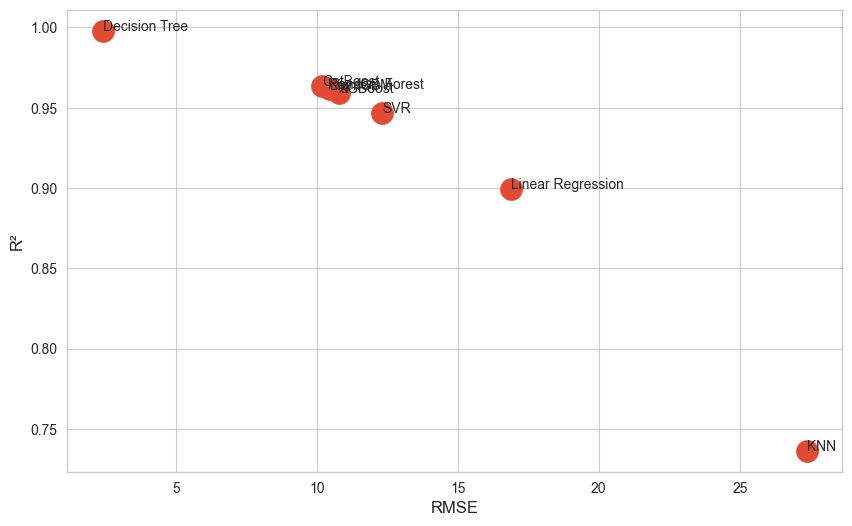

In [106]:
# ==============================================================================
# R2 VS RMSE
# ==============================================================================

plt.figure(figsize=(10,6))

plt.scatter(

    comparison["RMSE"],

    comparison["R2"],

    s=250

)

for i in range(len(comparison)):

    plt.text(

        comparison.iloc[i]["RMSE"],

        comparison.iloc[i]["R2"],

        comparison.iloc[i]["Model"]

    )

plt.xlabel("RMSE")

plt.ylabel("R²")

plt.show()

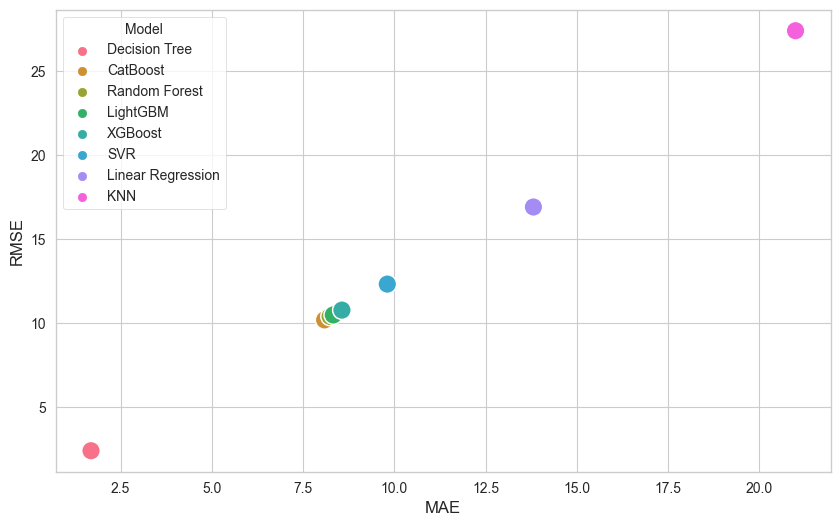

In [108]:
# ==============================================================================
# MAE VS RMSE
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=comparison,

    x="MAE",

    y="RMSE",

    hue="Model",

    s=180

)

plt.show()

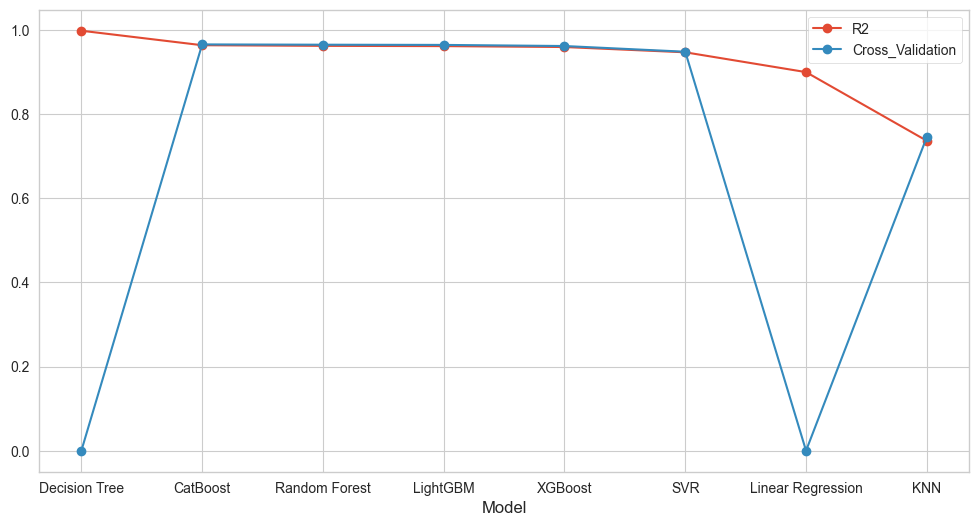

In [109]:
# ==============================================================================
# LINE CHART
# ==============================================================================

comparison.set_index("Model")[["R2","Cross_Validation"]].plot(

    figsize=(12,6),

    marker="o"

)

plt.show()

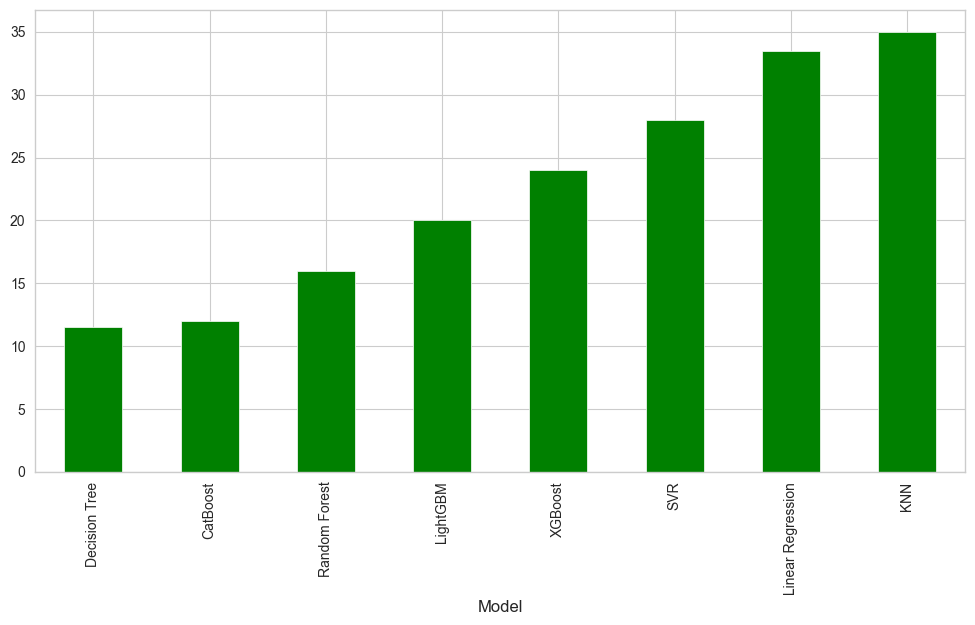

In [110]:
# ==============================================================================
# BAR CHART
# ==============================================================================

comparison.set_index("Model")["Overall_Rank"].plot(

    kind="bar",

    figsize=(12,6),

    color="green"

)

plt.show()

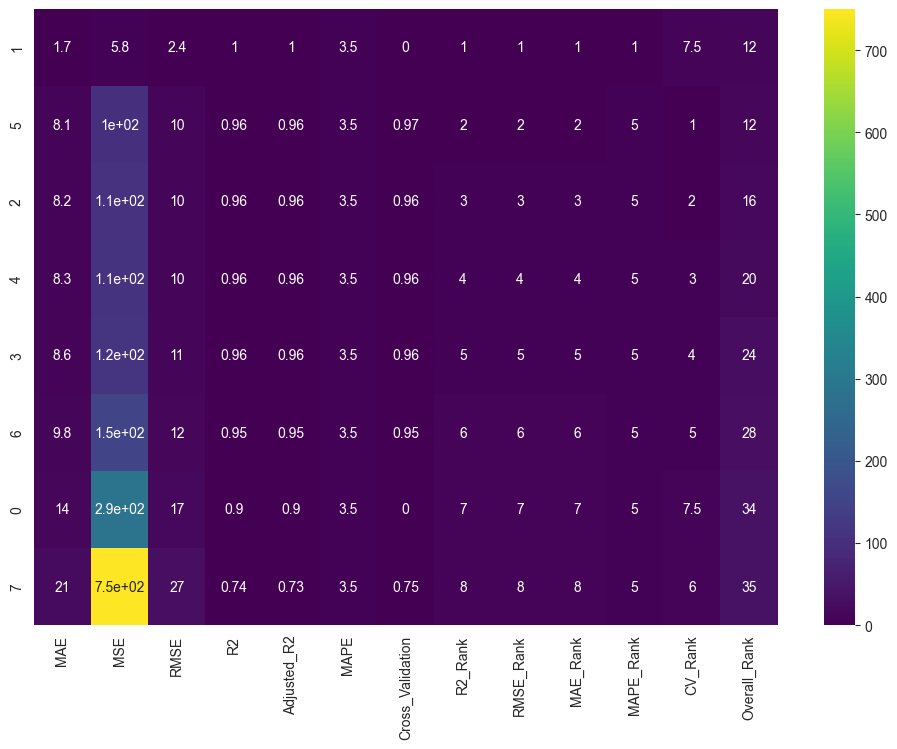

In [111]:
# ==============================================================================
# HEATMAP
# ==============================================================================

plt.figure(figsize=(12,8))

sns.heatmap(

    comparison.drop(columns="Model"),

    annot=True,

    cmap="viridis"

)

plt.show()

In [112]:
# ==============================================================================
# SAVE FINAL RESULT
# ==============================================================================

comparison.to_excel(

    "dataset/Final_Model_Comparison.xlsx",

    index=False

)

print("Excel Saved")

Excel Saved


In [113]:
# ==============================================================================
# BEST MODEL INFORMATION
# ==============================================================================

comparison.iloc[0]

Model               Decision Tree
MAE                      1.689339
MSE                      5.797635
RMSE                     2.407828
R2                       0.997963
Adjusted_R2              0.997926
MAPE                     3.510447
Cross_Validation              0.0
R2_Rank                       1.0
RMSE_Rank                     1.0
MAE_Rank                      1.0
MAPE_Rank                     1.0
CV_Rank                       7.5
Overall_Rank                 11.5
Name: 1, dtype: object

In [114]:
# ==============================================================================
# MODEL COUNT
# ==============================================================================

print("Total Models :",len(comparison))

Total Models : 8


In [115]:
# ==============================================================================
# FEATURES USED
# ==============================================================================

print("Models Compared")

comparison["Model"]

Models Compared


1        Decision Tree
5             CatBoost
2        Random Forest
4             LightGBM
3              XGBoost
6                  SVR
0    Linear Regression
7                  KNN
Name: Model, dtype: object

In [116]:
# ==============================================================================
# BEST MODEL REPORT
# ==============================================================================

best_report = comparison.iloc[[0]]

best_report

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE,Cross_Validation,R2_Rank,RMSE_Rank,MAE_Rank,MAPE_Rank,CV_Rank,Overall_Rank
1,Decision Tree,1.689339,5.797635,2.407828,0.997963,0.997926,3.510447,0.0,1.0,1.0,1.0,1.0,7.5,11.5


In [117]:
# ==============================================================================
# EXPORT BEST MODEL REPORT
# ==============================================================================

best_report.to_csv(

    "dataset/Best_Model_Report.csv",

    index=False

)

print("Report Saved")

Report Saved


In [118]:
# ==============================================================================
# PROJECT SUMMARY
# ==============================================================================

print("Retail Demand Forecasting")

print("Models Compared :",len(comparison))

print("Best Model :",best_model)

Retail Demand Forecasting
Models Compared : 8
Best Model : Model               Decision Tree
MAE                      1.689339
MSE                      5.797635
RMSE                     2.407828
R2                       0.997963
Adjusted_R2              0.997926
MAPE                     3.510447
Cross_Validation              0.0
R2_Rank                       1.0
RMSE_Rank                     1.0
MAE_Rank                      1.0
MAPE_Rank                     1.0
CV_Rank                       7.5
Overall_Rank                 11.5
Name: 1, dtype: object


In [119]:
# ==============================================================================
# DASHBOARD READY
# ==============================================================================

print("Dashboard Ready")

Dashboard Ready


In [120]:
# ==============================================================================
# VERIFY DATASET
# ==============================================================================

print(os.listdir("dataset"))

['Best_Model_Report.csv', 'CatBoost_Performance.csv', 'catboost_predictions.csv', 'Comparison_Results.csv', 'Comparison_Summary.csv', 'DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'Final_Model_Comparison.xlsx', 'Final_Model_Ranking.csv', 'KNN_Performance.csv', 'knn_predictions.csv', 'LightGBM_Performance.csv', 'lightgbm_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'Model_Comparison.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv', 'SVR_Performance.csv', 'svr_predictions.csv', 'XGBoost_Performance.csv', 'xgboost_predictions.csv']


In [121]:
# ==============================================================================
# VERIFY MODEL
# ==============================================================================

print(os.listdir("model"))

['best_model.pkl', 'catboost_model.pkl', 'decision_tree.pkl', 'knn_model.pkl', 'knn_scaler.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'svr_model.pkl', 'svr_scaler.pkl', 'xgboost_model.pkl']


In [122]:
# ==============================================================================
# EXPORT FINAL CSV
# ==============================================================================

comparison.to_csv(

    "dataset/final_results.csv",

    index=False

)

print("CSV Saved")

CSV Saved


In [123]:
# ==============================================================================
# FINAL RECOMMENDATION
# ==============================================================================

print("Recommended Model")

print(best_model)

Recommended Model
Model               Decision Tree
MAE                      1.689339
MSE                      5.797635
RMSE                     2.407828
R2                       0.997963
Adjusted_R2              0.997926
MAPE                     3.510447
Cross_Validation              0.0
R2_Rank                       1.0
RMSE_Rank                     1.0
MAE_Rank                      1.0
MAPE_Rank                     1.0
CV_Rank                       7.5
Overall_Rank                 11.5
Name: 1, dtype: object


In [124]:
# ==============================================================================
# MODEL READY
# ==============================================================================

print("Prediction Model Ready")

Prediction Model Ready


In [125]:
# ==============================================================================
# STREAMLIT READY
# ==============================================================================

print("Ready For Streamlit Dashboard")

Ready For Streamlit Dashboard
